# Gabor filter bank on a real image

We use a small 2D Gabor filter bank on a real image of a brick wall.

## Main idea

For a fixed location $t_0$ and frequency $\omega_0$, one Gabor / STFT coefficient can be read in three equivalent ways.

### 1. Local patch view

$$
\widetilde{V}_w f(t_0,\omega_0)
=
\int_{\mathbb{R}} f(t_0+\tau)\,w(\tau)\,e^{-i\omega_0 \tau}\,d\tau
$$

This is the Fourier coefficient of the local patch centered at $t_0$.

### 2. Global-spectrum view

$$
\widetilde{V}_w f(t_0,\omega_0)
=
\frac{1}{2\pi}
\int_{\mathbb{R}}
\widehat{f}(\xi)\,\widehat{w}(\omega_0-\xi)\,e^{i\xi t_0}\,d\xi
$$

This is the inverse Fourier value at $t_0$ of the global spectrum filtered around $\omega_0$.

### 3. Filter / modulation view

$$
g_{t_0,\omega_0}(t)=w(t-t_0)e^{i\omega_0(t-t_0)},
\qquad
\widehat{g_{t_0,\omega_0}}(\omega)=e^{-i\omega t_0}\,\widehat{w}(\omega-\omega_0)
$$

So the atom is a localized band-pass filter.

## From 1D to 2D

In 2D, the same idea becomes an oriented Gabor filter bank.
Each filter selects:

- a **preferred orientation** $\theta$,
- a **preferred spatial frequency** $f$,
- and a **local neighborhood** because of the Gaussian window.

A typical 2D Gabor atom has the form

$$
g_{\theta,f}(x,y)
=
\exp\!\left(
-\frac{x_\theta^2+y_\theta^2}{2\sigma^2}
\right)
\,e^{\,i\,2\pi f x_\theta}
$$

where

$$
x_\theta = x\cos\theta + y\sin\theta,
\qquad
y_\theta = -x\sin\theta + y\cos\theta
$$

So a Gabor filter bank is a collection of localized, oriented band-pass filters.
On a brick wall image, some filters respond strongly to the dominant texture directions and scales.

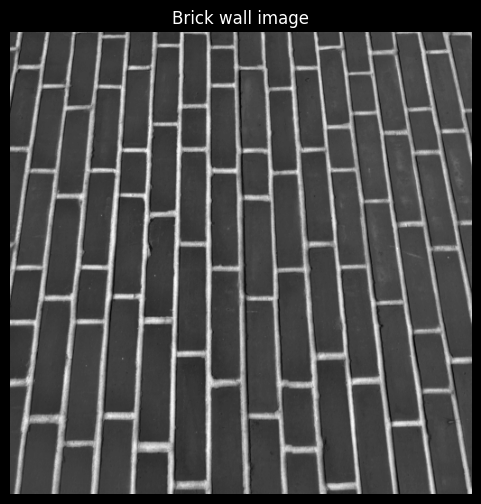

Image shape: (512, 512)
Intensity range: (np.float64(0.24705882352941178), np.float64(0.8117647058823529))


In [24]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_float
from skimage.filters import gabor, gabor_kernel
# Real image: brick wall
img = img_as_float(data.brick())

# Just in case the image is RGB in some versions
if img.ndim == 3:
    img = img.mean(axis=2)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, cmap="gray")
ax.set_title("Brick wall image")
ax.axis("off")
plt.show()

print("Image shape:", img.shape)
print("Intensity range:", (img.min(), img.max()))

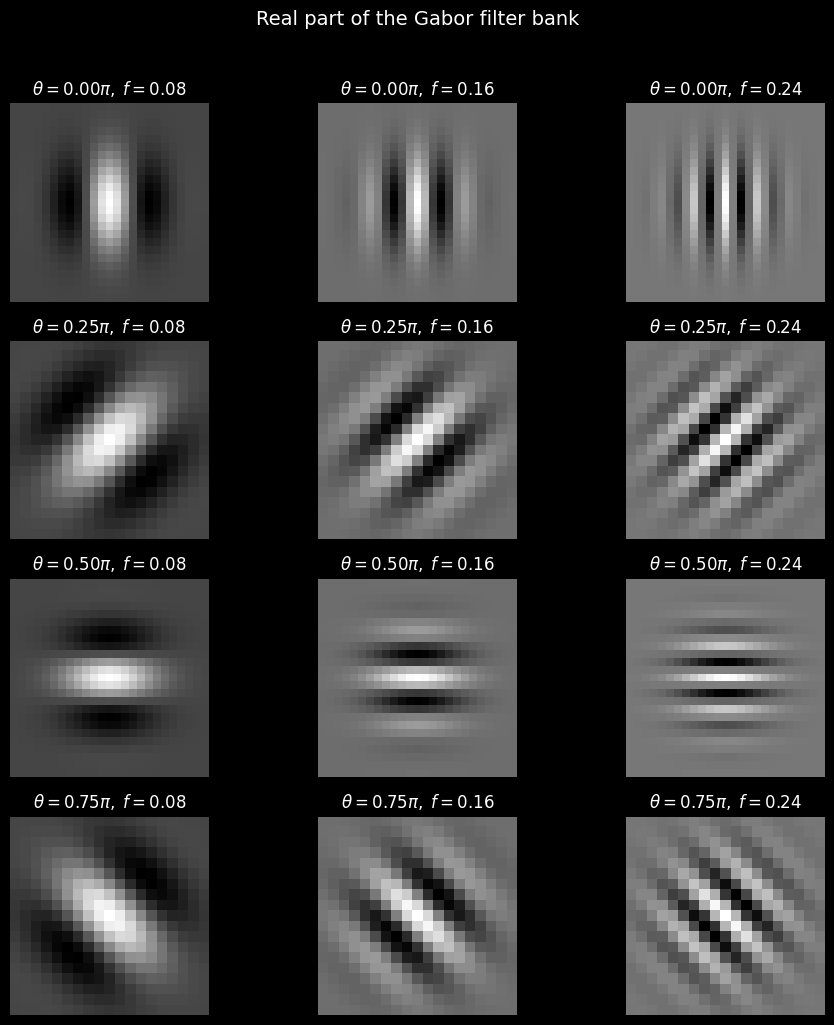

In [25]:
# Small Gabor filter bank
thetas = [0, np.pi/4, np.pi/2, 3*np.pi/4]
frequencies = [0.08, 0.16, 0.24]

fig, axes = plt.subplots(len(thetas), len(frequencies), figsize=(10, 10))

for i, theta in enumerate(thetas):
    for j, freq in enumerate(frequencies):
        kernel = np.real(
            gabor_kernel(
                frequency=freq,
                theta=theta,
                sigma_x=4,
                sigma_y=4
            )
        )

        ax = axes[i, j]
        ax.imshow(kernel, cmap="gray")
        ax.set_title(fr"$\theta={theta/np.pi:.2f}\pi,\; f={freq}$")
        ax.axis("off")

plt.suptitle("Real part of the Gabor filter bank", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

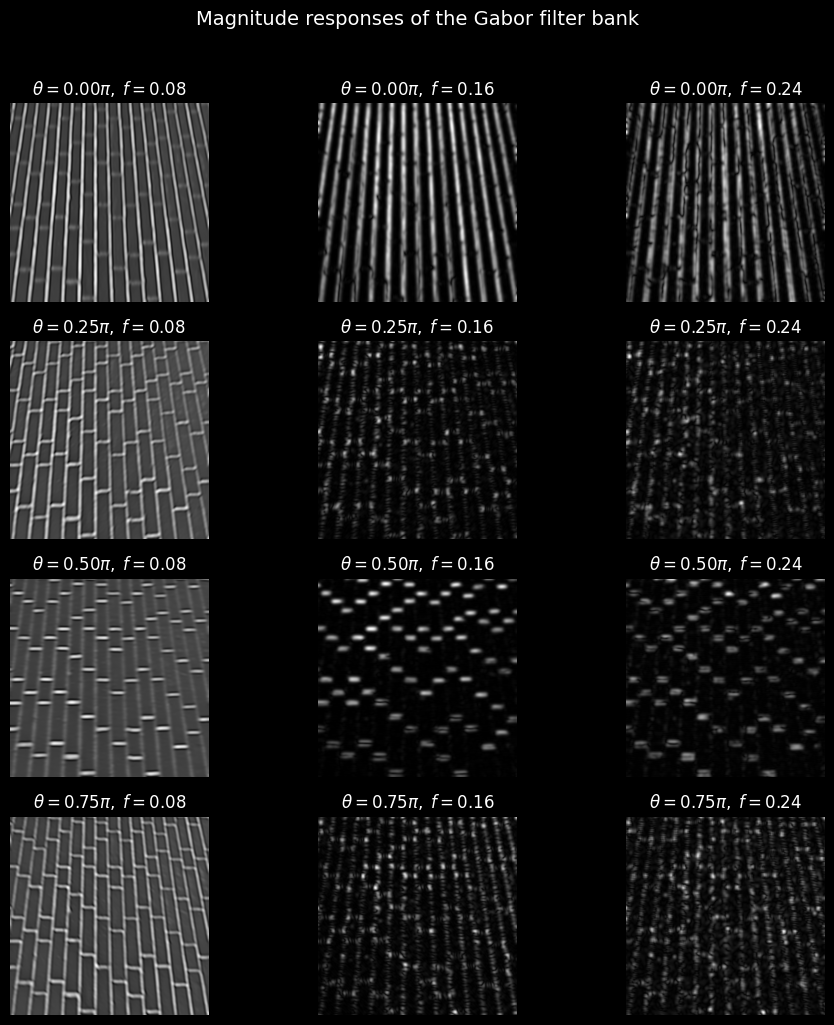

Filters ranked by mean response magnitude:

theta = 0.00π, frequency = 0.08, energy/mean magnitude = 0.063985
theta = 0.75π, frequency = 0.08, energy/mean magnitude = 0.063455
theta = 0.25π, frequency = 0.08, energy/mean magnitude = 0.063385
theta = 0.50π, frequency = 0.08, energy/mean magnitude = 0.058889
theta = 0.00π, frequency = 0.16, energy/mean magnitude = 0.012735
theta = 0.00π, frequency = 0.24, energy/mean magnitude = 0.004090
theta = 0.50π, frequency = 0.16, energy/mean magnitude = 0.003320
theta = 0.75π, frequency = 0.16, energy/mean magnitude = 0.001383
theta = 0.25π, frequency = 0.16, energy/mean magnitude = 0.001356
theta = 0.50π, frequency = 0.24, energy/mean magnitude = 0.001226
theta = 0.25π, frequency = 0.24, energy/mean magnitude = 0.000656
theta = 0.75π, frequency = 0.24, energy/mean magnitude = 0.000612


In [26]:
# Apply the filter bank and display magnitude responses
fig, axes = plt.subplots(len(thetas), len(frequencies), figsize=(10, 10))
energies = []

for i, theta in enumerate(thetas):
    for j, freq in enumerate(frequencies):
        real, imag = gabor(
            img,
            frequency=freq,
            theta=theta,
            sigma_x=4,
            sigma_y=4
        )

        magnitude = np.sqrt(real**2 + imag**2)
        energies.append((theta, freq, magnitude.mean()))

        ax = axes[i, j]
        ax.imshow(magnitude, cmap="gray")
        ax.set_title(fr"$\theta={theta/np.pi:.2f}\pi,\; f={freq}$")
        ax.axis("off")

plt.suptitle("Magnitude responses of the Gabor filter bank", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

energies = sorted(energies, key=lambda x: x[2], reverse=True)

print("Filters ranked by mean response magnitude:\n")
for theta, freq, e in energies:
    print(f"theta = {theta/np.pi:.2f}π, frequency = {freq:.2f}, mean magnitude = {e:.6f}")

## What this notebook shows

- Each Gabor filter is a **localized, oriented band-pass probe**.
- For each pixel, the filter bank asks:
  - which orientation fits best here?
  - which spatial frequency fits best here?
- The map of strongest response shows where the image contains texture aligned with one of the bank filters.
- The orientation map shows which filter direction best matches the local brick pattern.
- This is the 2D image version of the same idea as the STFT:
  - **local patch Fourier measurement**
  - **filtered global spectrum**
  - **response to a localized band-pass atom**e